In [28]:
import pandas as pd
import torch
import torch.nn as nn
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [41]:
df = pd.read_csv("/content/Data Sentimen MBG (1).csv")

## Ubah Label ke Angka

In [50]:
def auto_label(text):
    text = text.lower()

    positif = ['bagus','keren','mantap','baik','hebat','setuju','dukung']
    negatif = ['jelek','buruk','korupsi','maling','rusak','parah']

    if any(word in text for word in positif):
        return 1
    elif any(word in text for word in negatif):
        return 0
    else:
        return 0  # default negatif

df['label'] = df['text'].apply(auto_label)

In [51]:
print(df['label'].value_counts())

label
0    5629
1     790
Name: count, dtype: int64


In [52]:
print(df['label'].unique())

[0 1]


In [56]:
print(df.columns)

Index(['author', 'published_at', 'like_count', 'text', 'public', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'label_fix', 'label'],
      dtype='object')


## Cleaning Teks

In [57]:
def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['text'] = df['text'].apply(clean)

In [58]:
df['text'] = df['text'].str.lower()

In [59]:
import re

def cleaning(text):
    text = re.sub(r'http\S+', '', text)   # URL
    text = re.sub(r'@\w+', '', text)      # mention
    text = re.sub(r'#\w+', '', text)      # hashtag
    text = re.sub(r'[^a-z\s]', '', text)  # simbol & angka
    return text

df['text'] = df['text'].apply(cleaning)

## Tokenisasi

In [61]:
df['tokens'] = df['text'].apply(lambda x: x.split())

## Vocabulary

In [62]:
vocab = {}

for sentence in df['tokens']:
    for word in sentence:
        if word not in vocab:
            vocab[word] = len(vocab) + 1

## Stopword Removal

In [63]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Stemming

## Normalization

In [66]:
normal_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "bgt": "banget",
    "yg": "yang"
}

def normalize(words):
    return [normal_dict.get(word, word) for word in words]

df['tokens'] = df['tokens'].apply(normalize)

In [68]:
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))

## Encoding dan Padding

In [69]:
def encode(sentence):
    return [vocab[word] for word in sentence]

df['encoded'] = df['tokens'].apply(encode)

max_len = 30

def pad(seq):
    if len(seq) < max_len:
        seq = seq + [0]*(max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

df['padded'] = df['encoded'].apply(pad)

In [27]:
print("Awal:", len(df))

# setelah cleaning
print("Setelah cleaning:", len(df))

# setelah labeling
print("Setelah label:", len(df))

Awal: 0
Setelah cleaning: 0
Setelah label: 0


## Split Data

In [91]:
if df.empty:
    print("DataFrame 'df' is empty. Cannot perform train_test_split. Please check previous data processing steps.")
    X_train, X_val, X_test, y_train, y_val, y_test = torch.empty(0, 0), torch.empty(0, 0), torch.empty(0, 0), torch.empty(0), torch.empty(0), torch.empty(0)
else:
    X = torch.tensor(list(df['padded']))
    y = torch.tensor(df['label'].values, dtype=torch.long)

    # Add a check for X and y being empty even if df is not directly empty (e.g., if all padded sequences are empty after processing)
    if X.numel() == 0 or y.numel() == 0:
        print("Input tensors X or y are empty after processing. Cannot perform train_test_split.")
        X_train, X_val, X_test, y_train, y_val, y_test = torch.empty(0, 0), torch.empty(0, 0), torch.empty(0, 0), torch.empty(0), torch.empty(0), torch.empty(0)
    else:
        # First split: 70% train, 30% temp (for val and test)
        X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
        # Second split: 50% of temp for val, 50% of temp for test (15% val, 15% test of original)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [110]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=df['label']
)

weights = torch.tensor(class_weights, dtype=torch.float)

loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

print("Class Weights:", weights)

Class Weights: tensor([0.5702, 4.0627])


In [149]:
batch_size = 16
epochs = 20
learning_rate = 0.0005

## DataLoader

In [150]:
from torch.utils.data import DataLoader, TensorDataset

train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

In [151]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)

        _, (h_n, _) = self.lstm(x)

        out = h_n[-1]

        out = self.dropout(out)

        out = self.fc(out)
        return out

## Model LSTM

In [152]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        out = h_n[-1]
        out = self.dropout(out)
        out = self.fc(out)
        return out

In [153]:
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)

In [154]:
preds = torch.argmax(output, dim=1)
acc = (preds == y_batch).float().mean()

In [156]:
preds = torch.argmax(model(X_val), dim=1)
print(torch.unique(preds, return_counts=True))

(tensor([0, 1]), tensor([920,  43]))


In [158]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp
)

In [159]:
for name, param in model.named_parameters():
    if param.grad is None:
        print(name, "NO GRAD")

In [160]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [161]:
weights = torch.tensor([0.57, 4.06])
loss_fn = nn.CrossEntropyLoss(weight=weights)

In [164]:
import torch.nn as nn

class TemporaryLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(32, 32, batch_first=True, num_layers=2)



## Training

In [165]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(20):
    # ===== TRAINING =====
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # hitung akurasi
        preds = torch.argmax(output, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            output = model(X_batch)
            loss = loss_fn(output, y_batch)

            val_loss_total += loss.item()

            preds = torch.argmax(output, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = val_loss_total / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Train Loss: 0.6762 | Val Loss: 0.6712 | Train Acc: 0.8384 | Val Acc: 0.8609
Epoch 2 | Train Loss: 0.6624 | Val Loss: 0.6546 | Train Acc: 0.8549 | Val Acc: 0.8048
Epoch 3 | Train Loss: 0.6365 | Val Loss: 0.6629 | Train Acc: 0.7926 | Val Acc: 0.8546
Epoch 4 | Train Loss: 0.5727 | Val Loss: 0.5484 | Train Acc: 0.8182 | Val Acc: 0.8380
Epoch 5 | Train Loss: 0.4298 | Val Loss: 0.5155 | Train Acc: 0.8901 | Val Acc: 0.8037
Epoch 6 | Train Loss: 0.3108 | Val Loss: 0.4720 | Train Acc: 0.9197 | Val Acc: 0.8609
Epoch 7 | Train Loss: 0.2310 | Val Loss: 0.4669 | Train Acc: 0.9510 | Val Acc: 0.8245
Epoch 8 | Train Loss: 0.1844 | Val Loss: 0.6064 | Train Acc: 0.9657 | Val Acc: 0.8733
Epoch 9 | Train Loss: 0.1573 | Val Loss: 0.5682 | Train Acc: 0.9728 | Val Acc: 0.8193
Epoch 10 | Train Loss: 0.1202 | Val Loss: 0.6857 | Train Acc: 0.9826 | Val Acc: 0.9003
Epoch 11 | Train Loss: 0.1035 | Val Loss: 0.6167 | Train Acc: 0.9855 | Val Acc: 0.8951
Epoch 12 | Train Loss: 0.0845 | Val Loss: 0.6546 | T

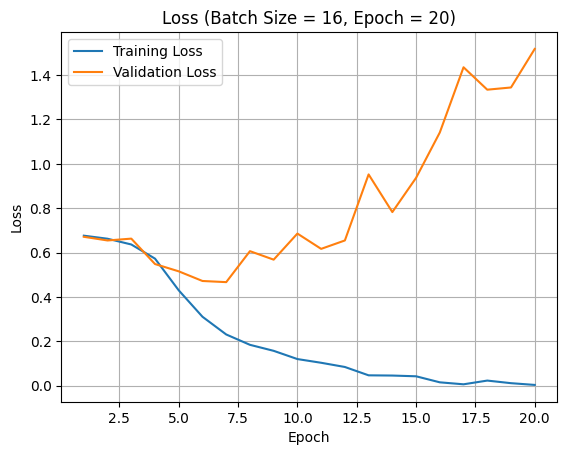

In [167]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

plt.title("Loss (Batch Size = 16, Epoch = 20)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

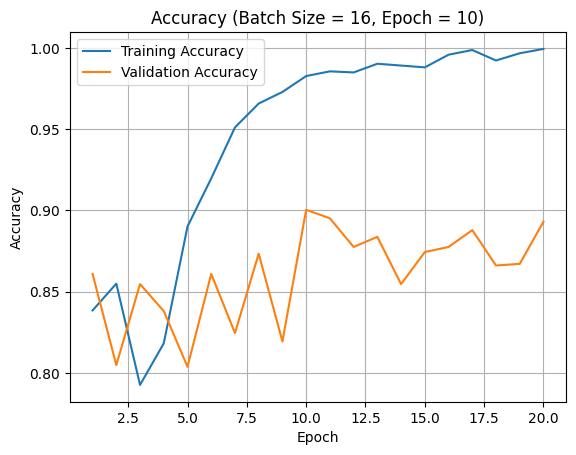

In [168]:
plt.figure()
plt.plot(epochs, train_accs, label='Training Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')

plt.title("Accuracy (Batch Size = 16, Epoch = 10)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

## Evaluasi

In [169]:
from torch.utils.data import DataLoader, TensorDataset

model.eval()
all_preds = []

# Ensure test_loader is correctly initialized with the current X_test and y_test
test_data = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=batch_size)

with torch.no_grad():
    for X_batch, _ in test_loader:
        output = model(X_batch)
        pred = torch.argmax(output, dim=1)
        all_preds.extend(pred.numpy())

print(classification_report(y_test, all_preds))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       844
           1       0.86      0.91      0.88       119

    accuracy                           0.97       963
   macro avg       0.92      0.94      0.93       963
weighted avg       0.97      0.97      0.97       963



# Confusion Matrix

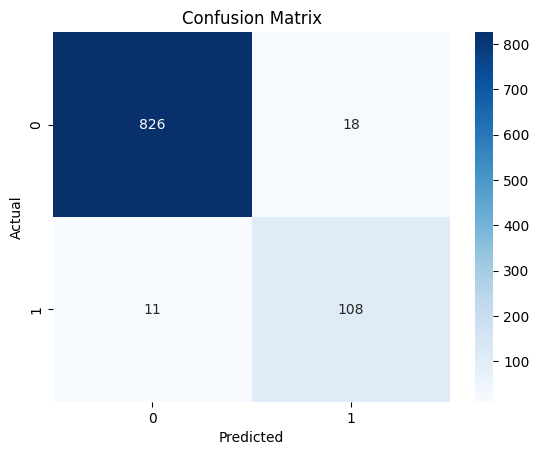

In [170]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

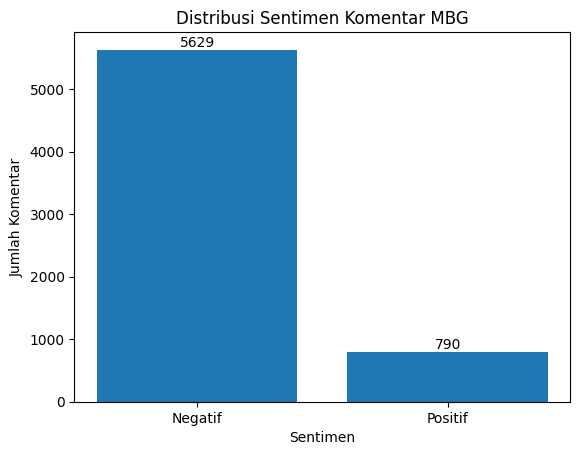

In [171]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

labels = ['Negatif', 'Positif']
values = [counts[0], counts[1]]

plt.figure()
plt.bar(labels, values)

# tampilkan angka
for i, v in enumerate(values):
    plt.text(i, v + 50, str(v), ha='center')

plt.title("Distribusi Sentimen Komentar MBG")
plt.ylabel("Jumlah Komentar")
plt.xlabel("Sentimen")

plt.show()

In [173]:
sample_text = df['text'].iloc[0]
sample_tokens = sample_text.split()
sample_encoded = [vocab[word] for word in sample_tokens]
sample_padded = sample_encoded + [0]*(10-len(sample_encoded))

print("Teks:", sample_text)
print("Token:", sample_tokens)
print("Index:", sample_encoded)
print("Padding:", sample_padded)

Teks: penguasa dan pelaksana program mbg menjadi penguasa naga ke  dari penguasa  naga
Token: ['penguasa', 'dan', 'pelaksana', 'program', 'mbg', 'menjadi', 'penguasa', 'naga', 'ke', 'dari', 'penguasa', 'naga']
Index: [1, 2, 3, 4, 5, 6, 1, 7, 8, 9, 1, 7]
Padding: [1, 2, 3, 4, 5, 6, 1, 7, 8, 9, 1, 7]


In [178]:
def model_summary(model):
    print(f"{'Layer':<20} {'Output Shape':<20} {'Param #':<15}")
    print("="*55)

    total_params = 0
    for name, param in model.named_parameters():
        param_count = param.numel()
        total_params += param_count
        # Dapatkan nama layer (tanpa weight/bias)
        layer_name = name.split('.')[0] if '.' in name else name
        print(f"{layer_name:<20} {str(list(param.shape)):20} {param_count:<15,}")

    print("="*55)
    print(f"{'Total Trainable Params':<40} {total_params:,}")
    return total_params
model = LSTMModel(vocab_size=len(vocab)+1, embed_dim=128, hidden_dim=128)
total_params = model_summary(model)

Layer                Output Shape         Param #        
embedding            [16383, 128]         2,097,024      
lstm                 [512, 128]           65,536         
lstm                 [512, 128]           65,536         
lstm                 [512]                512            
lstm                 [512]                512            
fc                   [2, 128]             256            
fc                   [2]                  2              
Total Trainable Params                   2,229,378
